In [ ]:
from ucimlrepo import fetch_ucirepo 
from C_PCA import C_PCA
from FDB import FDB_PCA
from DetMCD_PCA import DetMCD_PCA

import sys
import os
# get and add path to the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from utils import create_figures_directory
from FIR_PCA import FIR_PCA
import numpy as np
import matplotlib.pyplot as plt
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

  
# # metadata 
# print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# # variable information 
# print(breast_cancer_wisconsin_diagnostic.variables) 
# print(X.iloc[:, 30])
# print(X.head())
print(y.head())
# get unique names from dianosis column y
names = y.iloc[:, 0].unique()
print(names)
# get number of entries for each unique name in y
counts = y.value_counts()
print(counts)

# get indices where y is equal to M or B
M_indices = np.where(y == 'M')
B_indices = np.where(y == 'B')

# get 100% of M and 50% of B
M_indices = M_indices[0]
B_indices = B_indices[0][:int(len(B_indices[0])/4)]
# combine the indices
M_indices = M_indices.tolist()
B_indices = B_indices.tolist()
selected_indices = M_indices + B_indices

X = X.iloc[selected_indices, :].values
b_indices = np.arange(len(B_indices))
m_indices = np.arange(len(M_indices)) + len(B_indices)


# X = X.iloc[:, :-1].values
X = np.array(X)
# normalize data for each feature
X = (X - X.mean(axis=0)) / X.std(axis=0)

# C-PCA 
pca_scores, pca_m, pca_l, pca_p, pca_sd, pca_od, pca_sd_cuttoff, pca_od_cuttoff = C_PCA(X)
pca_H_sd = np.setdiff1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )
pca_H_od = np.setdiff1d( np.where(pca_od > pca_od_cuttoff), np.where(pca_sd > pca_sd_cuttoff) )
pca_H_sd_od = np.intersect1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )

# DetMCD
detmcd_scores, detmcd_M, detmcd_L, detmcd_P, detmcd_sd, detmcd_od, detmcd_sd_cutoff, detmcd_od_cutoff = DetMCD_PCA(X, alpha=0.75)  
detmcd_H_sd = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
detmcd_H_od = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
detmcd_H_sd_od = np.intersect1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )

# FDB-PCA
fdb_scores,fdb_M, fdb_L, fdb_P, fdb_sd, fdb_od, fdb_sd_cuttoff, fdb_od_cuttoff, fdb_H = FDB_PCA(X, alpha=0.75)
fdb_H_sd = np.setdiff1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fdb_H_od = np.setdiff1d( np.where(fdb_od > fdb_od_cuttoff), np.where(fdb_sd > fdb_sd_cuttoff) )
fdb_H_sd_od = np.intersect1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fig, ax = plt.subplots(2, 4, figsize=(10, 5))

# FIR-PCA
fir_scores,fir_M, fir_L, fir_P, fir_sd, fir_od, fir_sd_cuttoff, fir_od_cutoff, fir_H = FIR_PCA(X, alpha=0.75)
fir_H_sd = np.setdiff1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )
fir_H_od = np.setdiff1d( np.where(fir_od > fir_od_cutoff), np.where(fir_sd > fir_sd_cuttoff) )
fir_H_sd_od = np.intersect1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )


# ax[0, 0].scatter(pca_sd, pca_od)
ax[0, 0].scatter(pca_sd[m_indices], pca_od[m_indices], color='k', label='M')
ax[0, 0].scatter(pca_sd[b_indices], pca_od[b_indices], color='b', label='B')
ax[0, 0].axvline(pca_sd_cuttoff, color='r', linestyle='--')
ax[0, 0].axhline(pca_od_cuttoff, color='r', linestyle='--')
ax[1, 0].scatter(pca_sd[pca_H_sd], pca_od[pca_H_sd], color='r', marker='x')
ax[0, 0].set_title('PCA')

# ax[0, 1].scatter(detmcd_sd, detmcd_od)
ax[0, 1].scatter(detmcd_sd[m_indices], detmcd_od[m_indices], color='k', label='M')
ax[0, 1].scatter(detmcd_sd[b_indices], detmcd_od[b_indices], color='b', label='B')
ax[0, 1].axvline(detmcd_sd_cutoff, color='r', linestyle='--')
ax[0, 1].axhline(detmcd_od_cutoff, color='r', linestyle='--')
ax[1, 1].scatter(detmcd_sd[detmcd_H_sd], detmcd_od[detmcd_H_sd], color='r', marker='x')
ax[0, 1].set_title('DetMCD')

# ax[0, 2].scatter(fdb_sd, fdb_od)
ax[0, 2].scatter(fdb_sd[m_indices], fdb_od[m_indices], color='k', label='M')
ax[0, 2].scatter(fdb_sd[b_indices], fdb_od[b_indices], color='b', label='B')
ax[0, 2].axvline(fdb_sd_cuttoff, color='r', linestyle='--')
ax[0, 2].axhline(fdb_od_cuttoff, color='r', linestyle='--')
ax[1, 2].scatter(fdb_sd[fdb_H], fdb_od[fdb_H], color='r', marker='x')
ax[0, 0].set_title('FDB-PCA')

# ax[0, 3].scatter(fir_sd, fir_od)
ax[0, 3].scatter(fir_sd[m_indices], fir_od[m_indices], color='k', label='M')
ax[0, 3].scatter(fir_sd[b_indices], fir_od[b_indices], color='b', label='B')
ax[0, 3].axvline(fir_sd_cuttoff, color='r', linestyle='--')
ax[0, 3].axhline(fir_od_cutoff, color='r', linestyle='--')
ax[1, 3].scatter(fir_sd[fir_H], fir_od[fir_H], color='r', marker='x')
ax[0, 3].set_title('FIR-PCA')


plt.show()




In [ ]:
from ucimlrepo import fetch_ucirepo 
from C_PCA import C_PCA
from FDB import FDB_PCA
from DetMCD_PCA import DetMCD_PCA

import sys
import os
# get and add path to the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from utils import create_figures_directory
from FIR_PCA import FIR_PCA
import numpy as np
import matplotlib.pyplot as plt
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=16) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

  
# # metadata 
# print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# # variable information 
# print(breast_cancer_wisconsin_diagnostic.variables) 
# print(X.iloc[:, 30])
print(X.head())
print(y.head())
# get unique names from dianosis column y
names = y.iloc[:, 0].unique()
print(names)
# get number of entries for each unique name in y
counts = y.value_counts()
print(counts)

# get indices where y is equal to M or B
M_indices = np.where(y == 'N')
B_indices = np.where(y == 'R')

# get 100% of M and 50% of B
M_indices = M_indices[0]
B_indices = B_indices[0][:int(len(B_indices[0])/1)]
# combine the indices
M_indices = M_indices.tolist()
B_indices = B_indices.tolist()
selected_indices = M_indices + B_indices

X = X.iloc[selected_indices, :].values
# replace NaN values with 0
X = np.nan_to_num(X)
b_indices = np.arange(len(B_indices))
m_indices = np.arange(len(M_indices)) + len(B_indices)


# X = X.iloc[:, :-1].values
X = np.array(X)
# normalize data for each feature
X = (X - X.mean(axis=0)) / X.std(axis=0)

# C-PCA 
pca_scores, pca_m, pca_l, pca_p, pca_sd, pca_od, pca_sd_cuttoff, pca_od_cuttoff = C_PCA(X)
pca_H_sd = np.setdiff1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )
pca_H_od = np.setdiff1d( np.where(pca_od > pca_od_cuttoff), np.where(pca_sd > pca_sd_cuttoff) )
pca_H_sd_od = np.intersect1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )

# DetMCD
detmcd_scores, detmcd_M, detmcd_L, detmcd_P, detmcd_sd, detmcd_od, detmcd_sd_cutoff, detmcd_od_cutoff = DetMCD_PCA(X, alpha=0.5)  
detmcd_H_sd = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
detmcd_H_od = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
detmcd_H_sd_od = np.intersect1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )

# FDB-PCA
fdb_scores,fdb_M, fdb_L, fdb_P, fdb_sd, fdb_od, fdb_sd_cuttoff, fdb_od_cuttoff, fdb_H = FDB_PCA(X, alpha=0.5)
fdb_H_sd = np.setdiff1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fdb_H_od = np.setdiff1d( np.where(fdb_od > fdb_od_cuttoff), np.where(fdb_sd > fdb_sd_cuttoff) )
fdb_H_sd_od = np.intersect1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fig, ax = plt.subplots(2, 4, figsize=(10, 5))

# FIR-PCA
fir_scores,fir_M, fir_L, fir_P, fir_sd, fir_od, fir_sd_cuttoff, fir_od_cutoff, fir_H = FIR_PCA(X, alpha=0.5)
fir_H_sd = np.setdiff1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )
fir_H_od = np.setdiff1d( np.where(fir_od > fir_od_cutoff), np.where(fir_sd > fir_sd_cuttoff) )
fir_H_sd_od = np.intersect1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )


# ax[0, 0].scatter(pca_sd, pca_od)
ax[0, 0].scatter(pca_sd[m_indices], pca_od[m_indices], color='k', label='M')
ax[0, 0].scatter(pca_sd[b_indices], pca_od[b_indices], color='b', label='B')
ax[0, 0].axvline(pca_sd_cuttoff, color='r', linestyle='--')
ax[0, 0].axhline(pca_od_cuttoff, color='r', linestyle='--')
ax[1, 0].scatter(pca_sd[pca_H_sd], pca_od[pca_H_sd], color='r', marker='x')
ax[0, 0].set_title('PCA')

# ax[0, 1].scatter(detmcd_sd, detmcd_od)
ax[0, 1].scatter(detmcd_sd[m_indices], detmcd_od[m_indices], color='k', label='M')
ax[0, 1].scatter(detmcd_sd[b_indices], detmcd_od[b_indices], color='b', label='B')
ax[0, 1].axvline(detmcd_sd_cutoff, color='r', linestyle='--')
ax[0, 1].axhline(detmcd_od_cutoff, color='r', linestyle='--')
ax[1, 1].scatter(detmcd_sd[detmcd_H_sd], detmcd_od[detmcd_H_sd], color='r', marker='x')
ax[0, 1].set_title('DetMCD')

# ax[0, 2].scatter(fdb_sd, fdb_od)
ax[0, 2].scatter(fdb_sd[m_indices], fdb_od[m_indices], color='k', label='M')
ax[0, 2].scatter(fdb_sd[b_indices], fdb_od[b_indices], color='b', label='B')
ax[0, 2].axvline(fdb_sd_cuttoff, color='r', linestyle='--')
ax[0, 2].axhline(fdb_od_cuttoff, color='r', linestyle='--')
ax[1, 2].scatter(fdb_sd[fdb_H], fdb_od[fdb_H], color='r', marker='x')
ax[0, 0].set_title('FDB-PCA')

# ax[0, 3].scatter(fir_sd, fir_od)
ax[0, 3].scatter(fir_sd[m_indices], fir_od[m_indices], color='k', label='M')
ax[0, 3].scatter(fir_sd[b_indices], fir_od[b_indices], color='b', label='B')
ax[0, 3].axvline(fir_sd_cuttoff, color='r', linestyle='--')
ax[0, 3].axhline(fir_od_cutoff, color='r', linestyle='--')
ax[1, 3].scatter(fir_sd[fir_H], fir_od[fir_H], color='r', marker='x')
ax[0, 3].set_title('FIR-PCA')


plt.show()




In [ ]:
from ucimlrepo import fetch_ucirepo 
from C_PCA import C_PCA
from FDB import FDB_PCA
from DetMCD_PCA import DetMCD_PCA

import sys
import os
# get and add path to the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from utils import create_figures_directory
from FIR_PCA import FIR_PCA
import numpy as np
import matplotlib.pyplot as plt
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=52) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

  
# # metadata 
# print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# # variable information 
# print(breast_cancer_wisconsin_diagnostic.variables) 
# print(X.iloc[:, 30])
print(X.head())
print(y.head())
# get unique names from dianosis column y
names = y.iloc[:, 0].unique()
print(names)

counts = y.value_counts()
print(counts)

# get indices where y is equal to M or B
M_indices = np.where(y == 'g')
B_indices = np.where(y == 'b')

# get 100% of M and 50% of B
M_indices = M_indices[0]
B_indices = B_indices[0][:int(len(B_indices[0])/1)]
# combine the indices
M_indices = M_indices.tolist()
B_indices = B_indices.tolist()
selected_indices = M_indices + B_indices

X = X.iloc[selected_indices, :].values
# replace NaN values with 0
X = np.nan_to_num(X)
# remove rows with NaN values
X = X[~np.isnan(X).any(axis=1)]
b_indices = np.arange(len(B_indices))
m_indices = np.arange(len(M_indices)) + len(B_indices)


# X = X.iloc[:, :-1].values
X = np.array(X)
# normalize data for each feature
x_mean = X.mean(axis=0)
x_std = X.std(axis=0)
# remove with zero standard deviation
X = X[:, x_std != 0]
X = (X - X.mean(axis=0)) / X.std(axis=0)

# C-PCA 
pca_scores, pca_m, pca_l, pca_p, pca_sd, pca_od, pca_sd_cuttoff, pca_od_cuttoff = C_PCA(X)
pca_H_sd = np.setdiff1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )
pca_H_od = np.setdiff1d( np.where(pca_od > pca_od_cuttoff), np.where(pca_sd > pca_sd_cuttoff) )
pca_H_sd_od = np.intersect1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )

# # DetMCD
# detmcd_scores, detmcd_M, detmcd_L, detmcd_P, detmcd_sd, detmcd_od, detmcd_sd_cutoff, detmcd_od_cutoff = DetMCD_PCA(X, alpha=0.75, reweighting=False)  
# detmcd_H_sd = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
# detmcd_H_od = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
# detmcd_H_sd_od = np.intersect1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )

# FDB-PCA
fdb_scores,fdb_M, fdb_L, fdb_P, fdb_sd, fdb_od, fdb_sd_cuttoff, fdb_od_cuttoff, fdb_H = FDB_PCA(X, alpha=0.5, reweighting=False)
fdb_H_sd = np.setdiff1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fdb_H_od = np.setdiff1d( np.where(fdb_od > fdb_od_cuttoff), np.where(fdb_sd > fdb_sd_cuttoff) )
fdb_H_sd_od = np.intersect1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fig, ax = plt.subplots(2, 4, figsize=(10, 5))

# FIR-PCA
fir_scores,fir_M, fir_L, fir_P, fir_sd, fir_od, fir_sd_cuttoff, fir_od_cutoff, fir_H = FIR_PCA(X, alpha=0.5, reweighting=False)
fir_H_sd = np.setdiff1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )
fir_H_od = np.setdiff1d( np.where(fir_od > fir_od_cutoff), np.where(fir_sd > fir_sd_cuttoff) )
fir_H_sd_od = np.intersect1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )


# ax[0, 0].scatter(pca_sd, pca_od)
ax[0, 0].scatter(pca_sd[m_indices], pca_od[m_indices], color='k', label='M')
ax[0, 0].scatter(pca_sd[b_indices], pca_od[b_indices], color='b', label='B')
ax[0, 0].axvline(pca_sd_cuttoff, color='r', linestyle='--')
ax[0, 0].axhline(pca_od_cuttoff, color='r', linestyle='--')
ax[1, 0].scatter(pca_sd[pca_H_sd], pca_od[pca_H_sd], color='r', marker='x')
ax[0, 0].set_title('PCA')

# # ax[0, 1].scatter(detmcd_sd, detmcd_od)
# ax[0, 1].scatter(detmcd_sd[m_indices], detmcd_od[m_indices], color='k', label='M')
# ax[0, 1].scatter(detmcd_sd[b_indices], detmcd_od[b_indices], color='b', label='B')
# ax[0, 1].axvline(detmcd_sd_cutoff, color='r', linestyle='--')
# ax[0, 1].axhline(detmcd_od_cutoff, color='r', linestyle='--')
# ax[1, 1].scatter(detmcd_sd[detmcd_H_sd], detmcd_od[detmcd_H_sd], color='r', marker='x')
# ax[0, 1].set_title('DetMCD')

# ax[0, 2].scatter(fdb_sd, fdb_od)
ax[0, 2].scatter(fdb_sd[m_indices], fdb_od[m_indices], color='k', label='M')
ax[0, 2].scatter(fdb_sd[b_indices], fdb_od[b_indices], color='b', label='B')
ax[0, 2].axvline(fdb_sd_cuttoff, color='r', linestyle='--')
ax[0, 2].axhline(fdb_od_cuttoff, color='r', linestyle='--')
ax[1, 2].scatter(fdb_sd[fdb_H], fdb_od[fdb_H], color='r', marker='x')
ax[0, 0].set_title('FDB-PCA')

# ax[0, 3].scatter(fir_sd, fir_od)
ax[0, 3].scatter(fir_sd[m_indices], fir_od[m_indices], color='k', label='M')
ax[0, 3].scatter(fir_sd[b_indices], fir_od[b_indices], color='b', label='B')
ax[0, 3].axvline(fir_sd_cuttoff, color='r', linestyle='--')
ax[0, 3].axhline(fir_od_cutoff, color='r', linestyle='--')
ax[1, 3].scatter(fir_sd[fir_H], fir_od[fir_H], color='r', marker='x')
ax[0, 3].set_title('FIR-PCA')


plt.show()


        

      V1     V2     V3     V4     V5     V6     V7     V8     V9
1  0.153 -0.259  0.140  0.514  2.242  0.443 -0.021 -0.035 -0.065
2  0.119 -0.309  0.132  0.518  2.269  0.458 -0.018 -0.035 -0.053
3  0.173 -0.296  0.138  0.516  2.266  0.461 -0.023 -0.026 -0.052
4  0.135 -0.306  0.139  0.522  2.288  0.464 -0.015 -0.031 -0.051
5  0.143 -0.278  0.139  0.519  2.284  0.465 -0.016 -0.018 -0.054
C_PCA: r_80=7
DetMCD_PCA: r0=9, r1=9, r_80=2
FDB-PCA r_80: 4
FIR-PCA r_80: 4


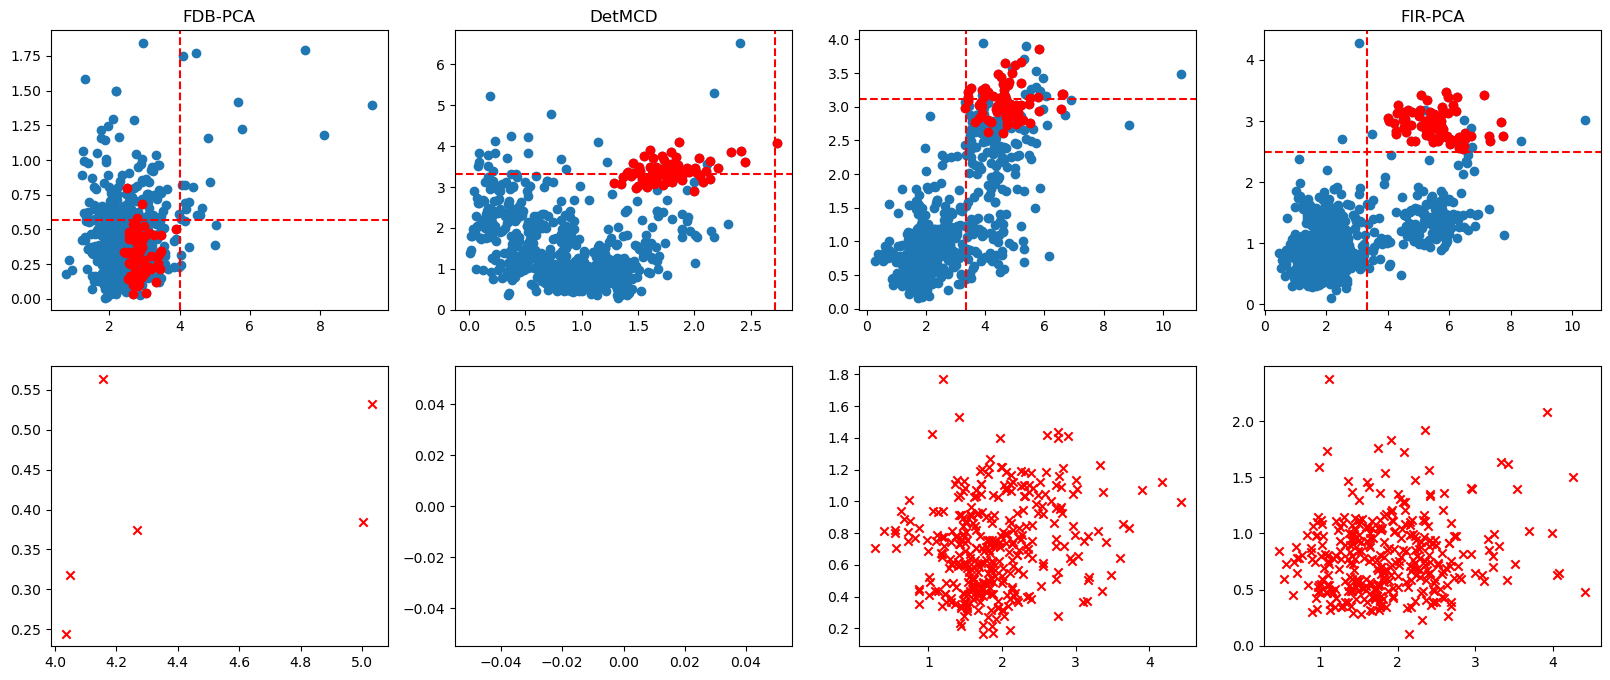

In [2]:
from ucimlrepo import fetch_ucirepo 
from C_PCA import C_PCA
from FDB import FDB_PCA
from DetMCD_PCA import DetMCD_PCA
import pandas as pd

import sys
import os
# get and add path to the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from utils import create_figures_directory
from FIR_PCA import FIR_PCA
import numpy as np
import matplotlib.pyplot as plt
# fetch dataset 
data = pd.read_csv('data/TVsets.txt', sep=' ')
print(data.head())


X = data.values

# normalize data for each feature
X = (X - X.mean(axis=0)) / X.std(axis=0)

out_indices = np.arange(490, 565)

# C-PCA 
pca_scores, pca_m, pca_l, pca_p, pca_sd, pca_od, pca_sd_cuttoff, pca_od_cuttoff = C_PCA(X)
pca_H_sd = np.setdiff1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )
pca_H_od = np.setdiff1d( np.where(pca_od > pca_od_cuttoff), np.where(pca_sd > pca_sd_cuttoff) )
pca_H_sd_od = np.intersect1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )

# DetMCD
detmcd_scores, detmcd_M, detmcd_L, detmcd_P, detmcd_sd, detmcd_od, detmcd_sd_cutoff, detmcd_od_cutoff = DetMCD_PCA(X, alpha=0.5, reweighting=False)  
detmcd_H_sd = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
detmcd_H_od = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
detmcd_H_sd_od = np.intersect1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )

# FDB-PCA
fdb_scores,fdb_M, fdb_L, fdb_P, fdb_sd, fdb_od, fdb_sd_cuttoff, fdb_od_cuttoff, fdb_H = FDB_PCA(X, alpha=0.5, reweighting=False)
fdb_H_sd = np.setdiff1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fdb_H_od = np.setdiff1d( np.where(fdb_od > fdb_od_cuttoff), np.where(fdb_sd > fdb_sd_cuttoff) )
fdb_H_sd_od = np.intersect1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fig, ax = plt.subplots(2, 4, figsize=(20, 8))

# FIR-PCA
fir_scores,fir_M, fir_L, fir_P, fir_sd, fir_od, fir_sd_cuttoff, fir_od_cutoff, fir_H = FIR_PCA(X, alpha=0.5, reweighting=False)
fir_H_sd = np.setdiff1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )
fir_H_od = np.setdiff1d( np.where(fir_od > fir_od_cutoff), np.where(fir_sd > fir_sd_cuttoff) )
fir_H_sd_od = np.intersect1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )


ax[0, 0].scatter(pca_sd, pca_od)
ax[0, 0].scatter(pca_sd[out_indices], pca_od[out_indices], color='r', label='Outliers')
# ax[0, 0].scatter(pca_sd[m_indices], pca_od[m_indices], color='k', label='M')
# ax[0, 0].scatter(pca_sd[b_indices], pca_od[b_indices], color='b', label='B')
ax[0, 0].axvline(pca_sd_cuttoff, color='r', linestyle='--')
ax[0, 0].axhline(pca_od_cuttoff, color='r', linestyle='--')
ax[1, 0].scatter(pca_sd[pca_H_sd], pca_od[pca_H_sd], color='r', marker='x')
ax[0, 0].set_title('PCA')

ax[0, 1].scatter(detmcd_sd, detmcd_od)
ax[0, 1].scatter(detmcd_sd[out_indices], detmcd_od[out_indices], color='r', label='Outliers')
# ax[0, 1].scatter(detmcd_sd[m_indices], detmcd_od[m_indices], color='k', label='M')
# ax[0, 1].scatter(detmcd_sd[b_indices], detmcd_od[b_indices], color='b', label='B')
ax[0, 1].axvline(detmcd_sd_cutoff, color='r', linestyle='--')
ax[0, 1].axhline(detmcd_od_cutoff, color='r', linestyle='--')
ax[1, 1].scatter(detmcd_sd[detmcd_H_sd], detmcd_od[detmcd_H_sd], color='r', marker='x')
ax[0, 1].set_title('DetMCD')

ax[0, 2].scatter(fdb_sd, fdb_od)
ax[0, 2].scatter(fdb_sd[out_indices], fdb_od[out_indices], color='r', label='Outliers')
# ax[0, 2].scatter(fdb_sd[m_indices], fdb_od[m_indices], color='k', label='M')
# ax[0, 2].scatter(fdb_sd[b_indices], fdb_od[b_indices], color='b', label='B')
ax[0, 2].axvline(fdb_sd_cuttoff, color='r', linestyle='--')
ax[0, 2].axhline(fdb_od_cuttoff, color='r', linestyle='--')
ax[1, 2].scatter(fdb_sd[fdb_H], fdb_od[fdb_H], color='r', marker='x')
ax[0, 0].set_title('FDB-PCA')

ax[0, 3].scatter(fir_sd, fir_od)
ax[0, 3].scatter(fir_sd[out_indices], fir_od[out_indices], color='r', label='Outliers')
# ax[0, 3].scatter(fir_sd[m_indices], fir_od[m_indices], color='k', label='M')
# ax[0, 3].scatter(fir_sd[b_indices], fir_od[b_indices], color='b', label='B')
ax[0, 3].axvline(fir_sd_cuttoff, color='r', linestyle='--')
ax[0, 3].axhline(fir_od_cutoff, color='r', linestyle='--')
ax[1, 3].scatter(fir_sd[fir_H], fir_od[fir_H], color='r', marker='x')
ax[0, 3].set_title('FIR-PCA')


plt.show()



In [ ]:
from ucimlrepo import fetch_ucirepo 
from C_PCA import C_PCA
from FDB import FDB_PCA
from DetMCD_PCA import DetMCD_PCA
import pandas as pd

import sys
import os
# get and add path to the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from utils import create_figures_directory
from FIR_PCA import FIR_PCA
import numpy as np
import matplotlib.pyplot as plt
# fetch dataset 
data = pd.read_csv('data/Ionosphere.txt', sep=' ')
print(data.head())


X = data.values

# normalize data for each feature
# X = (X - X.mean(axis=0)) / X.std(axis=0)

# C-PCA 
pca_scores, pca_m, pca_l, pca_p, pca_sd, pca_od, pca_sd_cuttoff, pca_od_cuttoff = C_PCA(X)
pca_H_sd = np.setdiff1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )
pca_H_od = np.setdiff1d( np.where(pca_od > pca_od_cuttoff), np.where(pca_sd > pca_sd_cuttoff) )
pca_H_sd_od = np.intersect1d( np.where(pca_sd > pca_sd_cuttoff), np.where(pca_od > pca_od_cuttoff) )

# DetMCD
detmcd_scores, detmcd_M, detmcd_L, detmcd_P, detmcd_sd, detmcd_od, detmcd_sd_cutoff, detmcd_od_cutoff = DetMCD_PCA(X, alpha=0.5, reweighting=False)  
detmcd_H_sd = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
detmcd_H_od = np.setdiff1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )
detmcd_H_sd_od = np.intersect1d( np.where(detmcd_sd > detmcd_sd_cutoff), np.where(detmcd_od > detmcd_od_cutoff) )

# FDB-PCA
fdb_scores,fdb_M, fdb_L, fdb_P, fdb_sd, fdb_od, fdb_sd_cuttoff, fdb_od_cuttoff, fdb_H = FDB_PCA(X, alpha=0.5, reweighting=False)
fdb_H_sd = np.setdiff1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fdb_H_od = np.setdiff1d( np.where(fdb_od > fdb_od_cuttoff), np.where(fdb_sd > fdb_sd_cuttoff) )
fdb_H_sd_od = np.intersect1d( np.where(fdb_sd > fdb_sd_cuttoff), np.where(fdb_od > fdb_od_cuttoff) )
fig, ax = plt.subplots(2, 4, figsize=(20, 8))

# FIR-PCA
fir_scores,fir_M, fir_L, fir_P, fir_sd, fir_od, fir_sd_cuttoff, fir_od_cutoff, fir_H = FIR_PCA(X, alpha=0.5, reweighting=False)
fir_H_sd = np.setdiff1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )
fir_H_od = np.setdiff1d( np.where(fir_od > fir_od_cutoff), np.where(fir_sd > fir_sd_cuttoff) )
fir_H_sd_od = np.intersect1d( np.where(fir_sd > fir_sd_cuttoff), np.where(fir_od > fir_od_cutoff) )


ax[0, 0].scatter(pca_sd, pca_od)
# ax[0, 0].scatter(pca_sd[m_indices], pca_od[m_indices], color='k', label='M')
# ax[0, 0].scatter(pca_sd[b_indices], pca_od[b_indices], color='b', label='B')
ax[0, 0].axvline(pca_sd_cuttoff, color='r', linestyle='--')
ax[0, 0].axhline(pca_od_cuttoff, color='r', linestyle='--')
ax[1, 0].scatter(pca_sd[pca_H_sd], pca_od[pca_H_sd], color='r', marker='x')
ax[0, 0].set_title('PCA')

ax[0, 1].scatter(detmcd_sd, detmcd_od)
# ax[0, 1].scatter(detmcd_sd[m_indices], detmcd_od[m_indices], color='k', label='M')
# ax[0, 1].scatter(detmcd_sd[b_indices], detmcd_od[b_indices], color='b', label='B')
ax[0, 1].axvline(detmcd_sd_cutoff, color='r', linestyle='--')
ax[0, 1].axhline(detmcd_od_cutoff, color='r', linestyle='--')
ax[1, 1].scatter(detmcd_sd[detmcd_H_sd], detmcd_od[detmcd_H_sd], color='r', marker='x')
ax[0, 1].set_title('DetMCD')

ax[0, 2].scatter(fdb_sd, fdb_od)
# ax[0, 2].scatter(fdb_sd[m_indices], fdb_od[m_indices], color='k', label='M')
# ax[0, 2].scatter(fdb_sd[b_indices], fdb_od[b_indices], color='b', label='B')
ax[0, 2].axvline(fdb_sd_cuttoff, color='r', linestyle='--')
ax[0, 2].axhline(fdb_od_cuttoff, color='r', linestyle='--')
ax[1, 2].scatter(fdb_sd[fdb_H], fdb_od[fdb_H], color='r', marker='x')
ax[0, 0].set_title('FDB-PCA')

ax[0, 3].scatter(fir_sd, fir_od)
# ax[0, 3].scatter(fir_sd[m_indices], fir_od[m_indices], color='k', label='M')
# ax[0, 3].scatter(fir_sd[b_indices], fir_od[b_indices], color='b', label='B')
ax[0, 3].axvline(fir_sd_cuttoff, color='r', linestyle='--')
ax[0, 3].axhline(fir_od_cutoff, color='r', linestyle='--')
ax[1, 3].scatter(fir_sd[fir_H], fir_od[fir_H], color='r', marker='x')
ax[0, 3].set_title('FIR-PCA')


plt.show()
